# LangGraph MCP Filesystem 튜토리얼

이 튜토리얼에서는 LangGraph와 MCP(Model Context Protocol)를 활용하여 **파일시스템 작업**을 수행하는 AI 에이전트를 구축합니다. MCP Filesystem 서버는 파일 읽기/쓰기, 디렉토리 탐색, 파일 검색 등 다양한 파일시스템 도구를 제공합니다.

> 참고 자료: [MCP Filesystem Server](https://github.com/modelcontextprotocol/servers/tree/main/src/filesystem)

### MCP Filesystem Server 주요 도구

| 도구 | 설명 |
|------|------|
| `read_text_file` | 텍스트 파일 내용 읽기 (`head`/`tail` 파라미터 지원) |
| `read_media_file` | 이미지/오디오 파일을 base64로 읽기 |
| `read_multiple_files` | 여러 파일 동시 읽기 |
| `write_file` | 파일 생성 또는 덮어쓰기 |
| `edit_file` | 패턴 매칭을 통한 선택적 편집 (dry run 지원) |
| `create_directory` | 디렉토리 생성 |
| `list_directory` | 디렉토리 내용 목록 조회 |
| `list_directory_with_sizes` | 크기 정보 포함 디렉토리 목록 |
| `move_file` | 파일/디렉토리 이동 또는 이름 변경 |
| `search_files` | 파일/디렉토리 재귀 검색 |
| `directory_tree` | 디렉토리 트리 구조 JSON 반환 |
| `get_file_info` | 파일/디렉토리 상세 메타데이터 |
| `list_allowed_directories` | 접근 허용된 디렉토리 목록 |

### 사전 준비

MCP Filesystem 서버는 Node.js 패키지이므로 **Node.js**와 **npx**가 설치되어 있어야 합니다.

```bash
# Node.js 설치 확인
node --version
npx --version
```

## 환경 설정

튜토리얼을 시작하기 전에 필요한 환경을 설정합니다. `dotenv`를 사용하여 API 키를 로드하고, `langchain_teddynote`의 로깅 설정을 활성화하여 LangSmith에서 실행 결과를 확인할 수 있도록 합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 프로젝트 추적 프로젝트 이름 설정
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


## 라이브러리 임포트 및 MCP 클라이언트 설정

LangGraph 에이전트 구성에 필요한 라이브러리를 임포트하고, MCP 클라이언트 설정을 위한 유틸리티 함수를 정의합니다.

In [2]:
import nest_asyncio
from typing import List, Dict, Any

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# MCP 클라이언트: 여러 MCP 서버에 연결하여 도구를 가져옵니다
from langchain_mcp_adapters.client import MultiServerMCPClient

# 비동기 호환성 활성화 (Jupyter 환경에서 필요)
nest_asyncio.apply()

In [3]:
import sys, os, subprocess

# Windows + Jupyter workaround: MCP stdio passes Jupyter's sys.stderr to subprocess.Popen,
# but Jupyter's stderr doesn't support fileno(). Patch the default errlog to os.devnull.
if sys.platform == "win32":
    import mcp.client.stdio as _mcp_stdio

    _devnull_file = open(os.devnull, "w")

    # @asynccontextmanager wraps the original function — patch __wrapped__.__defaults__
    if hasattr(_mcp_stdio.stdio_client, "__wrapped__"):
        _mcp_stdio.stdio_client.__wrapped__.__defaults__ = (_devnull_file,)

    # Also patch the helper that creates the subprocess
    _mcp_stdio._create_platform_compatible_process.__defaults__ = (
        None,
        _devnull_file,
        None,
    )


async def setup_mcp_client(server_configs: dict):
    """MCP 클라이언트를 설정하고 도구를 가져옵니다.

    Args:
        server_configs: 서버 구성 딕셔너리. 각 서버의 이름을 키로,
                       연결 정보(command, args, transport 또는 url)를 값으로 가집니다.

    Returns:
        tuple: (MCP 클라이언트, 로드된 도구 목록)
    """
    # MCP 클라이언트 생성
    client = MultiServerMCPClient(server_configs)

    # 서버에 연결하여 도구 목록을 가져옵니다
    tools = await client.get_tools()

    # 로드된 도구 목록을 출력합니다
    print(f"[MCP] {len(tools)}개의 도구가 로드되었습니다:")
    for tool in tools:
        print(f"  - {tool.name}")

    return client, tools

---

## Part 1: MCP Filesystem 서버 연결

MCP Filesystem 서버는 `@modelcontextprotocol/server-filesystem` npm 패키지로 제공됩니다. `npx`를 통해 별도 설치 없이 바로 실행할 수 있으며, stdio 전송 방식으로 클라이언트와 통신합니다.

서버 시작 시 **접근 허용 디렉토리**를 인자로 전달해야 합니다. 에이전트는 지정된 디렉토리 내에서만 파일시스템 작업을 수행할 수 있습니다.

아래 코드에서 `ALLOWED_DIR` 변수를 에이전트가 접근할 디렉토리 경로로 변경하세요.

In [4]:
import os

# 에이전트가 접근할 디렉토리 경로를 지정합니다 (본인의 환경에 맞게 수정하세요)
ALLOWED_DIR = os.path.abspath("./workspace")

# 작업 디렉토리가 없으면 생성합니다
os.makedirs(ALLOWED_DIR, exist_ok=True)

print(f"작업 디렉토리: {ALLOWED_DIR}")

작업 디렉토리: d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace


아래 코드는 MCP Filesystem 서버를 stdio 방식으로 연결하고 사용 가능한 도구 목록을 로드합니다.

In [5]:
# Filesystem MCP 서버 설정 (stdio 전송 방식)
server_configs = {
    "filesystem": {
        "command": "npx",
        "args": [
            "-y",
            "@modelcontextprotocol/server-filesystem",
            ALLOWED_DIR,  # 접근 허용 디렉토리
        ],
        "transport": "stdio",
    },
}

# MCP 클라이언트 생성 및 도구 로드
client, tools = await setup_mcp_client(server_configs)

[MCP] 14개의 도구가 로드되었습니다:
  - read_file
  - read_text_file
  - read_media_file
  - read_multiple_files
  - write_file
  - edit_file
  - create_directory
  - list_directory
  - list_directory_with_sizes
  - directory_tree
  - move_file
  - search_files
  - get_file_info
  - list_allowed_directories


---

## Part 2: Filesystem 에이전트 생성

MCP Filesystem 도구를 사용하는 에이전트를 생성합니다. `create_agent`는 LangChain v1에서 제공하는 에이전트 생성 함수로, LLM과 도구를 결합하여 추론-행동 루프를 자동으로 구성합니다.

> 참고: LangGraph v1에서 기존의 `create_react_agent`는 deprecated 되었으며, `langchain.agents.create_agent`를 사용하는 것이 권장됩니다.

In [6]:
# LLM 설정
# OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능
llm = init_chat_model("claude-sonnet-4-5", temperature=0)

# 에이전트 생성: MCP Filesystem 도구를 사용하는 에이전트
agent = create_agent(
    llm,
    tools,
    checkpointer=InMemorySaver(),  # 대화 상태를 메모리에 저장
)

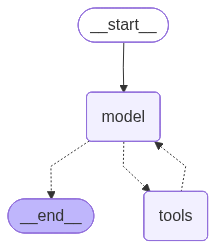

In [7]:
agent

In [8]:
# 스트리밍 출력 함수와 UUID 생성 함수를 import합니다
from langchain_teddynote.messages import astream_graph, random_uuid
from langchain_core.runnables import RunnableConfig

---

## Part 3: 허용된 디렉토리 확인

먼저 에이전트가 접근할 수 있는 디렉토리를 확인합니다. `list_allowed_directories` 도구를 통해 서버가 허용한 경로를 조회합니다.

In [9]:
# 대화 스레드 ID를 생성합니다
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: 허용된 디렉토리 확인
response = await astream_graph(
    agent,
    inputs={"messages": [("human", "접근 가능한 디렉토리 목록을 알려주세요.")]},
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Allowed directories:
D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
접근 가능한 디렉토리는 다음과 같습니다:

**D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace**

이 디렉토리와 그 하위 디렉토리들에 대해 파일 읽기, 쓰기, 검색 등의 작업을 수행할 수 있습니다. 이 디렉토리 내에서 어떤 작업을 도와드릴까요?

---

## Part 4: 파일 생성 및 쓰기

에이전트에게 파일을 생성하도록 요청합니다. `write_file` 도구를 사용하여 지정된 디렉토리에 새 파일을 만듭니다.

In [10]:
# 새로운 대화 스레드 생성
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: 파일 생성 요청
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                f"'{ALLOWED_DIR}' 디렉토리에 'hello.txt' 파일을 만들어주세요. "
                "내용은 '안녕하세요! MCP Filesystem 서버를 통해 생성된 파일입니다.'로 작성해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
파일을 생성하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Successfully wrote to d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\hello.txt
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
완료했습니다! 'hello.txt' 파일이 성공적으로 생성되었습니다. 파일 내용은 "안녕하세요! MCP Filesystem 서버를 통해 생성된 파일입니다."로 작성되었습니다.

---

## Part 5: 파일 읽기

생성한 파일을 에이전트가 읽어서 내용을 확인합니다. `read_text_file` 도구가 사용됩니다.

In [11]:
# 에이전트 실행: 파일 읽기 (같은 스레드에서 이전 대화 컨텍스트 유지)
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "방금 만든 'hello.txt' 파일의 내용을 읽어주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
파일 내용을 읽어보겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! MCP Filesystem 서버를 통해 생성된 파일입니다.
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
파일 내용을 성공적으로 읽었습니다:

**hello.txt 내용:**
```
안녕하세요! MCP Filesystem 서버를 통해 생성된 파일입니다.
```

파일이 정상적으로 생성되고 내용도 올바르게 저장되었습니다!

---

## Part 6: 디렉토리 탐색 및 파일 검색

에이전트에게 디렉토리 구조를 탐색하고 파일을 검색하도록 요청합니다. `list_directory`, `directory_tree`, `search_files` 등의 도구가 활용됩니다.

In [12]:
# 새로운 대화 스레드 생성
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: 디렉토리 구조 탐색
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                f"'{ALLOWED_DIR}' 디렉토리의 전체 구조를 트리 형태로 보여주세요. "
                "파일 크기 정보도 함께 알려주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
해당 디렉토리의 구조를 트리 형태로 보여드리겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
[FILE] hello.txt                            75 B

Total: 1 files, 0 directories
Combined size: 75 B[
  {
    "name": "hello.txt",
    "type": "file"
  }
]
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
**디렉토리 구조:**

```
workspace/
└── hello.txt (75 B)
```

**상세 정보:**
- **총 파일 수**: 1개
- **총 디렉토리 수**: 0개
- **전체 크기**: 75 바이트

현재 workspace 디렉토리에는 `hello.txt` 파일 하나만 존재하며, 파일 크기는 75바이트입니다. 파일의 내용을 확인하시겠습니까?

In [13]:
# 에이전트 실행: 파일 검색
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                f"'{ALLOWED_DIR}' 디렉토리에서 '.txt' 확장자를 가진 모든 파일을 검색해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
'.txt' 확장자를 가진 모든 파일을 검색하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\hello.txt
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
**검색 결과:**

'.txt' 확장자를 가진 파일이 **1개** 발견되었습니다:

1. `D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\hello.txt`

이 파일의 내용을 확인하시겠습니까?

---

## Part 7: 복합 작업 — 프로젝트 구조 자동 생성

에이전트에게 여러 도구를 조합한 복합 작업을 요청합니다. 디렉토리 생성, 파일 생성, 파일 편집 등을 연속으로 수행하여 간단한 프로젝트 구조를 자동으로 만듭니다.

In [15]:
# 새로운 대화 스레드 생성
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: 프로젝트 구조 자동 생성
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                f"""'{ALLOWED_DIR}' 디렉토리 안에 다음과 같은 Python 프로젝트 구조를 만들어주세요:

my_project/
├── src/
│   ├── __init__.py (빈 파일)
│   └── main.py (간단한 Hello World 코드)
├── tests/
│   └── test_main.py (간단한 테스트 코드)
└── README.md (프로젝트 설명)

**중요**: 파일을 생성하기 전에 반드시 먼저 필요한 모든 디렉토리를 생성해주세요.
순서: 1) create_directory로 my_project, my_project/src, my_project/tests 디렉토리를 먼저 생성 → 2) 각 파일에 적절한 내용을 write_file로 작성""",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네, 순서대로 진행하겠습니다. 먼저 필요한 디렉토리들을 생성한 후, 각 파일을 작성하겠습니다.

## 1단계: 디렉토리 생성
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Successfully created directory d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\my_project\testsSuccessfully created directory d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\my_projectSuccessfully created directory d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\my_project\src
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
좋습니다! 디렉토리가 모두 생성되었습니다. 이제 각 파일을 생성하겠습니다.

## 2단계: 파일 생성
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Successfully wrote to d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\my_project\src\main.pySuccessfully wrote to d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\my_project\src\__init__.pySuccessfully wrote to d:\2026_Age

생성된 프로젝트 구조를 확인합니다.

In [16]:
# 에이전트 실행: 생성된 프로젝트 구조 확인
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "방금 만든 my_project 디렉토리의 전체 트리 구조를 보여주고, 각 파일의 내용도 읽어서 알려주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네, 먼저 디렉토리 트리 구조를 확인하고, 그 다음 모든 파일의 내용을 읽어드리겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
[
  {
    "name": "README.md",
    "type": "file"
  },
  {
    "name": "src",
    "type": "directory",
    "children": [
      {
        "name": "main.py",
        "type": "file"
      },
      {
        "name": "__init__.py",
        "type": "file"
      }
    ]
  },
  {
    "name": "tests",
    "type": "directory",
    "children": [
      {
        "name": "test_main.py",
        "type": "file"
      }
    ]
  }
]
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\my_project\README.md:
# My Project

A simple Python project demonstrating basic project structure and testing.

## Project Structure

```
my_project/
├── src/
│   ├── __init__.py       # Pack

---

## Part 8: 파일 편집 및 이동

기존 파일을 편집하거나 이동하는 작업을 수행합니다. `edit_file` 도구는 패턴 매칭을 통해 파일의 특정 부분만 수정할 수 있으며, `move_file` 도구로 파일을 이동하거나 이름을 변경할 수 있습니다.

In [17]:
# 에이전트 실행: 파일 편집
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "my_project/src/main.py 파일을 수정해주세요. "
                "'Hello World' 대신 'Hello LangGraph MCP!'로 변경하고, "
                "현재 날짜를 출력하는 코드도 추가해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네, main.py 파일을 수정하겠습니다. 기본 인사말을 'Hello LangGraph MCP!'로 변경하고, 현재 날짜를 출력하는 기능을 추가하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
```diff
Index: D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\my_project\src\main.py
--- D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\my_project\src\main.py	original
+++ D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace\my_project\src\main.py	modified
@@ -1,9 +1,12 @@
 """
 Simple Hello World application
 """
 
-def greet(name: str = "World") -> str:
+from datetime import datetime
+
+
+def greet(name: str = "LangGraph MCP") -> str:
     """
     Returns a greeting message.
     
     Args:
@@ -14,13 +17,28 @@
     """
     return f"Hello, {name}!"
 
 
+def get_current_date() -> str:
+    """
+    Returns the current date in a formatted string.
+    
+    Returns:
+        A formatted date string (YYYY-MM

In [18]:
# 에이전트 실행: 수정된 파일 확인
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "수정된 main.py 파일의 내용을 읽어서 확인해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네, 수정된 main.py 파일의 내용을 읽어서 확인해드리겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
"""
Simple Hello World application
"""

from datetime import datetime


def greet(name: str = "LangGraph MCP") -> str:
    """
    Returns a greeting message.
    
    Args:
        name: The name to greet (default: "World")
    
    Returns:
        A greeting string
    """
    return f"Hello, {name}!"


def get_current_date() -> str:
    """
    Returns the current date in a formatted string.
    
    Returns:
        A formatted date string (YYYY-MM-DD)
    """
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def main():
    """Main entry point of the application"""
    # Print greeting
    message = greet()
    print(message)
    
    # Print current date
    current_date = get_current_date()
    print(f"Current date and time: {current_date}")
    
    # Example with custom name
    custom_message = gr

---

## Part 9: 파일 메타데이터 조회

`get_file_info` 도구를 사용하여 파일의 상세 메타데이터(크기, 생성일, 수정일, 권한 등)를 확인합니다.

In [19]:
# 에이전트 실행: 파일 메타데이터 조회
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "my_project 디렉토리 안의 모든 파일에 대해 파일 정보(크기, 수정일 등)를 조회해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네, my_project 디렉토리 안의 모든 파일에 대한 정보를 조회하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
size: 1168
created: Sat Mar 28 2026 13:30:40 GMT+0900 (한국 표준시)
modified: Sat Mar 28 2026 13:30:40 GMT+0900 (한국 표준시)
accessed: Sat Mar 28 2026 13:31:08 GMT+0900 (한국 표준시)
isDirectory: false
isFile: true
permissions: 666size: 907
created: Sat Mar 28 2026 13:31:28 GMT+0900 (한국 표준시)
modified: Sat Mar 28 2026 13:31:28 GMT+0900 (한국 표준시)
accessed: Sat Mar 28 2026 13:31:48 GMT+0900 (한국 표준시)
isDirectory: false
isFile: true
permissions: 666size: 963
created: Sat Mar 28 2026 13:30:39 GMT+0900 (한국 표준시)
modified: Sat Mar 28 2026 13:30:39 GMT+0900 (한국 표준시)
accessed: Sat Mar 28 2026 13:31:08 GMT+0900 (한국 표준시)
isDirectory: false
isFile: true
permissions: 666size: 53
created: Sat Mar 28 2026 13:30:39 GMT+0900 (한국 표준시)
modified: Sat Mar 28 2026 13:30:39 GMT+0900 (한국 표준시)
accessed: Sat Mar 28 2026 13:31:08 GMT+0900 (한국 표준시)
isDi

---

## Part 10: 여러 디렉토리 접근 허용

MCP Filesystem 서버는 여러 디렉토리를 동시에 허용할 수 있습니다. 아래는 복수의 디렉토리를 지정하여 서버를 구성하는 예시입니다.

In [20]:
# 두 번째 작업 디렉토리 생성
ALLOWED_DIR_2 = os.path.abspath("./workspace2")
os.makedirs(ALLOWED_DIR_2, exist_ok=True)

# 여러 디렉토리를 허용하는 Filesystem MCP 서버 설정
multi_dir_server_configs = {
    "filesystem": {
        "command": "npx",
        "args": [
            "-y",
            "@modelcontextprotocol/server-filesystem",
            ALLOWED_DIR,    # 첫 번째 허용 디렉토리
            ALLOWED_DIR_2,  # 두 번째 허용 디렉토리
        ],
        "transport": "stdio",
    },
}

# MCP 클라이언트 생성 및 도구 로드
client2, tools2 = await setup_mcp_client(multi_dir_server_configs)

[MCP] 14개의 도구가 로드되었습니다:
  - read_file
  - read_text_file
  - read_media_file
  - read_multiple_files
  - write_file
  - edit_file
  - create_directory
  - list_directory
  - list_directory_with_sizes
  - directory_tree
  - move_file
  - search_files
  - get_file_info
  - list_allowed_directories


In [21]:
# 여러 디렉토리를 사용하는 에이전트 생성
agent2 = create_agent(
    init_chat_model("claude-sonnet-4-5", temperature=0),
    tools2,
    checkpointer=InMemorySaver(),
)

# 새로운 대화 스레드 생성
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: 허용된 디렉토리 목록 확인 후 파일 복사
response = await astream_graph(
    agent2,
    inputs={
        "messages": [
            (
                "human",
                "먼저 접근 가능한 디렉토리 목록을 확인한 후, "
                f"'{ALLOWED_DIR}/hello.txt' 파일의 내용을 읽어서 "
                f"'{ALLOWED_DIR_2}/hello_copy.txt'로 복사해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
먼저 접근 가능한 디렉토리를 확인하고, 파일을 읽은 후 복사하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Allowed directories:
D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace
D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace2안녕하세요! MCP Filesystem 서버를 통해 생성된 파일입니다.
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
좋습니다! 접근 가능한 디렉토리 두 곳을 확인했고, hello.txt 파일의 내용도 읽었습니다. 이제 workspace2 디렉토리에 hello_copy.txt 파일로 복사하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Successfully wrote to d:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace2/hello_copy.txt
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
완료했습니다! 

**작업 요약:**
1. ✅ 접근 가능한 디렉토리 확인:
   - `D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace`
   - `D:\2026_Agent\Teddy_langgraph\langgraph-v1-tutorial\06-MCP\workspace2`

2. ✅ 원본 파일 읽기: `work

---

## 정리

이 튜토리얼에서 다룬 내용을 정리합니다:

1. **MCP Filesystem 서버 연결**: `@modelcontextprotocol/server-filesystem`을 `npx`로 실행하고 `MultiServerMCPClient`로 연결
2. **디렉토리 접근 제어**: 서버 시작 시 허용 디렉토리를 지정하여 보안 경계 설정
3. **파일 CRUD 작업**: 파일 생성(`write_file`), 읽기(`read_text_file`), 편집(`edit_file`), 이동(`move_file`)
4. **디렉토리 탐색**: 목록 조회(`list_directory`), 트리 구조(`directory_tree`), 파일 검색(`search_files`)
5. **메타데이터 조회**: `get_file_info`로 파일 상세 정보 확인
6. **복수 디렉토리 지원**: 여러 디렉토리를 동시에 허용하여 에이전트의 작업 범위 확장

MCP Filesystem 서버를 활용하면 에이전트가 안전한 경계 내에서 파일시스템 작업을 자율적으로 수행할 수 있습니다.